In [1]:
!pip install torch torchvision scikit-learn tqdm scipy seaborn --quiet

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm
from collections import Counter
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from scipy.optimize import minimize
import random

In [3]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

Using device: cuda


In [4]:
IMG_SIZE = 224
PATCH_SIZE = 112
STRIDE = 56
BATCH_SIZE = 1
LR = 1e-4
PATCH_EPOCHS = 5
IMAGE_EPOCHS = 10
MC_RUNS = 50

In [5]:
def extract_patches(img):
    patches = []
    img = img.resize((IMG_SIZE, IMG_SIZE))
    for y in range(0, IMG_SIZE-PATCH_SIZE+1, STRIDE):
        for x in range(0, IMG_SIZE-PATCH_SIZE+1, STRIDE):
            patch = img.crop((x, y, x+PATCH_SIZE, y+PATCH_SIZE))
            patches.append(patch)
    return patches

In [6]:
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(90),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [7]:
class PatchDataset(Dataset):
    def __init__(self, root, transform):
        self.data = ImageFolder(root)
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img, label = self.data[idx]
        patches = extract_patches(img)
        patches = torch.stack([self.transform(p) for p in patches])
        return patches, label

In [8]:
train_path = "/kaggle/input/datasets/fanconic/skin-cancer-malignant-vs-benign/train"
test_path  = "/kaggle/input/datasets/fanconic/skin-cancer-malignant-vs-benign/test"
train_ds = PatchDataset(train_path, train_transform)
test_ds  = PatchDataset(test_path, test_transform)
train_loader = DataLoader(train_ds, batch_size=2, shuffle=True)
test_loader  = DataLoader(test_ds, batch_size=2)

In [9]:
print("Train images:", len(train_ds))
print("Test images:", len(test_ds))
print("Classes:", train_ds.data.classes)
labels_list = [train_ds.data.samples[i][1] for i in range(len(train_ds))]
print("Train distribution:", Counter(labels_list))

Train images: 2637
Test images: 660
Classes: ['benign', 'malignant']
Train distribution: Counter({0: 1440, 1: 1197})


In [10]:
class PatchCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3,32,3,padding=1),
            nn.ReLU(),
            nn.Dropout2d(0.3),
            nn.MaxPool2d(2),
            nn.Conv2d(32,64,3,padding=1),
            nn.ReLU(),
            nn.Dropout2d(0.4),
            nn.MaxPool2d(2),
            nn.Conv2d(64,128,3,padding=1),
            nn.ReLU(),
            nn.Dropout2d(0.5),
            nn.AdaptiveAvgPool2d(1)
        )
    def forward(self,x):
        x = self.conv(x)
        return x.view(x.size(0),-1)

In [11]:
class ImageClassifier(nn.Module):
    def __init__(self, feat_dim=256, num_classes=2):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(feat_dim,64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64,num_classes)
        )
    def forward(self, feats):
        mean_feat = feats.mean(dim=0)
        max_feat, _ = feats.max(dim=0)
        feats = torch.cat([mean_feat, max_feat]).unsqueeze(0)
        return self.fc(feats)

In [12]:
patch_model = PatchCNN().to(DEVICE)
patch_classifier = nn.Linear(128,2).to(DEVICE)
image_model = ImageClassifier(feat_dim=256).to(DEVICE)
criterion = nn.CrossEntropyLoss()

In [13]:
optimizer = torch.optim.Adam(
    list(patch_model.parameters()) + list(patch_classifier.parameters()), lr=LR)
patch_losses = []
for epoch in range(PATCH_EPOCHS):
    patch_model.train()
    patch_classifier.train()
    total_loss = 0
    for patches, label in tqdm(train_loader):
        # patches shape: [B, P, 3, 112, 112]
        patches = patches.to(DEVICE)
        label = label.to(DEVICE)
        B, P, C, H, W = patches.shape
        # Flatten patches for CNN
        patches = patches.view(B * P, C, H, W)
        # Forward
        feats = patch_model(patches)           # [B*P, 128]
        logits = patch_classifier(feats)       # [B*P, 2]
        # Repeat labels for each patch
        labels_patch = label.unsqueeze(1).repeat(1, P).view(-1)
        loss = criterion(logits, labels_patch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    epoch_loss = total_loss / len(train_loader)
    patch_losses.append(epoch_loss)
    print("Patch Epoch:", epoch, "Loss:", epoch_loss)

100%|██████████| 1319/1319 [00:47<00:00, 27.84it/s]


Patch Epoch: 0 Loss: 0.6001314528631025


100%|██████████| 1319/1319 [00:35<00:00, 36.93it/s]


Patch Epoch: 1 Loss: 0.5029705954296196


100%|██████████| 1319/1319 [00:35<00:00, 36.79it/s]


Patch Epoch: 2 Loss: 0.4806050796618147


100%|██████████| 1319/1319 [00:38<00:00, 33.88it/s]


Patch Epoch: 3 Loss: 0.4734913788713272


100%|██████████| 1319/1319 [00:38<00:00, 34.33it/s]

Patch Epoch: 4 Loss: 0.46328244734219387


In [14]:
optimizer = torch.optim.Adam(image_model.parameters(), lr=LR)
image_losses = []
for epoch in range(IMAGE_EPOCHS):
    image_model.train()
    patch_model.eval()   
    total_loss = 0
    for patches, label in tqdm(train_loader):
        patches = patches.to(DEVICE)
        label = label.to(DEVICE)
        B, P, C, H, W = patches.shape
        patches = patches.view(B * P, C, H, W)
        with torch.no_grad():
            feats = patch_model(patches) 
        feats = feats.view(B, P, -1)   
        outputs = []
        for i in range(B):
            out = image_model(feats[i])       
            outputs.append(out)
        out = torch.cat(outputs, dim=0)  
        loss = criterion(out, label)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    epoch_loss = total_loss / len(train_loader)
    image_losses.append(epoch_loss)
    print("Image Epoch:", epoch, "Loss:", epoch_loss)

100%|██████████| 1319/1319 [00:23<00:00, 54.98it/s]


Image Epoch: 0 Loss: 0.461875393806651


100%|██████████| 1319/1319 [00:24<00:00, 54.88it/s]


Image Epoch: 1 Loss: 0.42529140897886014


100%|██████████| 1319/1319 [00:23<00:00, 55.20it/s]


...

Image Epoch: 7 Loss: 0.4209057355985904


100%|██████████| 1319/1319 [00:24<00:00, 54.84it/s]


Image Epoch: 8 Loss: 0.4158434259657232


100%|██████████| 1319/1319 [00:24<00:00, 54.36it/s]

Image Epoch: 9 Loss: 0.4179395706498472


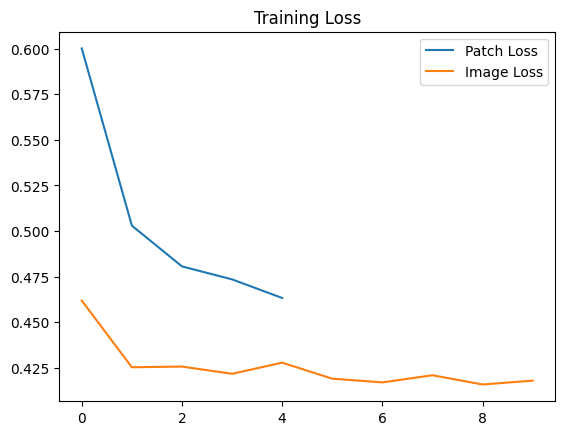

In [15]:
plt.plot(patch_losses, label="Patch Loss")
plt.plot(image_losses, label="Image Loss")
plt.legend()
plt.title("Training Loss")
plt.show()

In [16]:
def enable_dropout(model):
    for m in model.modules():
        if isinstance(m, (nn.Dropout, nn.Dropout2d)):
            m.train()

In [ ]:
y_true = []
y_pred = []
patch_model.eval()
image_model.eval()
enable_dropout(patch_model)
enable_dropout(image_model)
for patches, label in tqdm(test_loader):
    patches = patches.to(DEVICE)
    label = label.to(DEVICE)
    B, P, C, H, W = patches.shape
    patches = patches.view(B * P, C, H, W)
    with torch.no_grad():
        feats = patch_model(patches) 
    feats = feats.view(B, P, -1) 
    outputs = []
    for i in range(B):
        with torch.no_grad():
            out = image_model(feats[i]) 
        outputs.append(out)
    out = torch.cat(outputs, dim=0)        
    probs = F.softmax(out, dim=1).cpu().numpy()
    for i in range(B):
        y_true.append(label[i].item())
        y_pred.append(np.argmax(probs[i]))
baseline_acc = accuracy_score(y_true, y_pred)
print("Baseline Accuracy:", baseline_acc)

100%|██████████| 330/330 [00:08<00:00, 39.42it/s]


Baseline Accuracy: 0.803030303030303


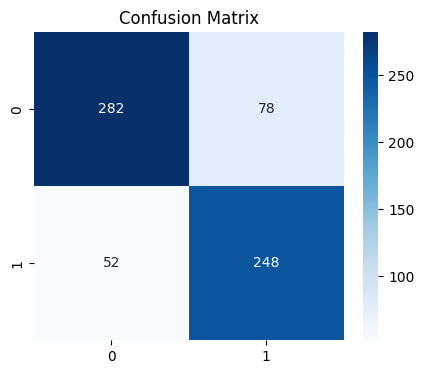

              precision    recall  f1-score   support

           0       0.84      0.78      0.81       360
           1       0.76      0.83      0.79       300

    accuracy                           0.80       660
   macro avg       0.80      0.80      0.80       660
weighted avg       0.81      0.80      0.80       660



In [18]:
cm = confusion_matrix(y_true,y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.title("Confusion Matrix")
plt.show()
print(classification_report(y_true,y_pred))

In [19]:
torch.save(patch_model.state_dict(),"patch_model.pth")
torch.save(image_model.state_dict(),"image_model.pth")
print("Models saved")

Models saved


In [20]:
def mc_predict(patches):
    preds = []
    
    for _ in range(MC_RUNS):
        with torch.no_grad():
            feats = patch_model(patches)        # (P, 128)
            out = image_model(feats)            # (1, 2)
            prob = F.softmax(out, dim=1).cpu().numpy()[0]
        
        preds.append(prob)

    preds = np.array(preds)
    
    mean_prob = preds.mean(axis=0)
    # uncertainty = preds.var(axis=0).sum()
    uncertainty = -np.sum(mean_prob * np.log(mean_prob + 1e-8))
    
    return mean_prob, uncertainty

In [21]:
probs = []
labels = []
uncs = []
patch_model.eval()
image_model.train() 
enable_dropout(patch_model)
enable_dropout(image_model)
for patches, label in tqdm(test_loader):
    patches = patches.to(DEVICE)
    label = label.to(DEVICE)
    B, P, C, H, W = patches.shape
    for i in range(B):
        single_patches = patches[i]       
        mean_prob, unc = mc_predict(single_patches)
        probs.append(mean_prob)
        labels.append(label[i].item())
        uncs.append(unc)
probs = np.array(probs)
labels = np.array(labels)
uncs = np.array(uncs)
print("Collected MC predictions")

100%|██████████| 330/330 [00:56<00:00,  5.85it/s]

Collected MC predictions


In [22]:
def cross_entropy(p, y):
    return -np.log(np.clip(p[y],1e-12,1))
def objective(lam):
    inc = uncs < lam
    exc = uncs >= lam
    if inc.sum()==0 or exc.sum()==0:
        return 999
    reject_rate = exc.sum()/len(uncs)
    if reject_rate > 0.5:
        return 999
    Hinc = np.mean([cross_entropy(probs[i], labels[i]) for i in range(len(probs)) if inc[i]])
    Hexc = np.mean([cross_entropy(probs[i], labels[i]) for i in range(len(probs)) if exc[i]])
    F = Hexc + (1 - Hinc)
    return F
from scipy.optimize import minimize
unc_min = float(uncs.min())
unc_max = float(uncs.max())
def cobyla_objective(lam):
    lam = lam[0]
    return objective(lam)
def c1(lam):
    return lam[0] - unc_min
def c2(lam):
    return unc_max - lam[0]
def c3(lam):
    lam = lam[0]
    exc = uncs >= lam
    reject_rate = exc.sum()/len(uncs)
    return 0.5 - reject_rate
def c4(lam):
    lam = lam[0]
    exc = uncs >= lam
    reject_rate = exc.sum()/len(uncs)
    return reject_rate - 0.05  
cons = [
    {'type':'ineq','fun':c1},
    {'type':'ineq','fun':c2},
    {'type':'ineq','fun':c3},
    {'type':'ineq','fun':c4}
]
result = minimize(
    cobyla_objective,
    x0=[(unc_min+unc_max)/2],
    method='COBYLA',
    constraints=cons,
    options={'maxiter':200}
)
best_lam = result.x[0]
print("Optimal λ =", best_lam)

Optimal λ = 0.6850323116829192


In [23]:
reject_rate = (uncs >= best_lam).sum() / len(uncs)
print("Rejected %:", reject_rate*100)

Rejected %: 8.484848484848486


In [24]:
inc_mask = uncs < best_lam     
exc_mask = uncs >= best_lam        
total_samples = len(uncs)
accepted = inc_mask.sum()
rejected = exc_mask.sum()
coverage = accepted / total_samples
reject_rate = rejected / total_samples
if accepted > 0:
    acc_inc = (probs[inc_mask].argmax(axis=1) == labels[inc_mask]).mean()
else:
    acc_inc = 0
if rejected > 0:
    acc_exc = (probs[exc_mask].argmax(axis=1) == labels[exc_mask]).mean()
else:
    acc_exc = 0
AD = acc_inc - acc_exc
AP = reject_rate * 100
print("FINAL RESULTS")
print("Baseline Accuracy:", round(baseline_acc,4))
print("MC Accepted Accuracy:", round(acc_inc,4))
print("Coverage %:", round(coverage*100,2))
print("Rejected %:", round(reject_rate*100,2))
print("Optimal Lambda:", best_lam)
print("DSF-CNN Metrics")
print("WAA Included:", round(acc_inc,4))
print("WAA Excluded:", round(acc_exc,4))
print("Accuracy Difference (AD):", round(AD,4))
print("Abstain Percentage (AP):", round(AP,2))

FINAL RESULTS
Baseline Accuracy: 0.803
MC Accepted Accuracy: 0.8245
Coverage %: 91.52
Rejected %: 8.48
Optimal Lambda: 0.6850323116829192
DSF-CNN Metrics
WAA Included: 0.8245
WAA Excluded: 0.5179
Accuracy Difference (AD): 0.3066
Abstain Percentage (AP): 8.48


In [25]:
import cv2
import matplotlib.pyplot as plt
import torch.nn.functional as F
def generate_spatial_uncertainty(patches, model):
    """Calculates variance for each patch to create a spatial heatmap."""
    model.train() 
    spatial_vars = []
    for p in patches:
        p = p.unsqueeze(0).to(DEVICE)
        preds = []
        for _ in range(MC_RUNS):
            with torch.no_grad():
                out = model(p)
                preds.append(out.cpu().numpy())
        spatial_vars.append(np.array(preds).var())
    return np.array(spatial_vars).reshape(3, 3)

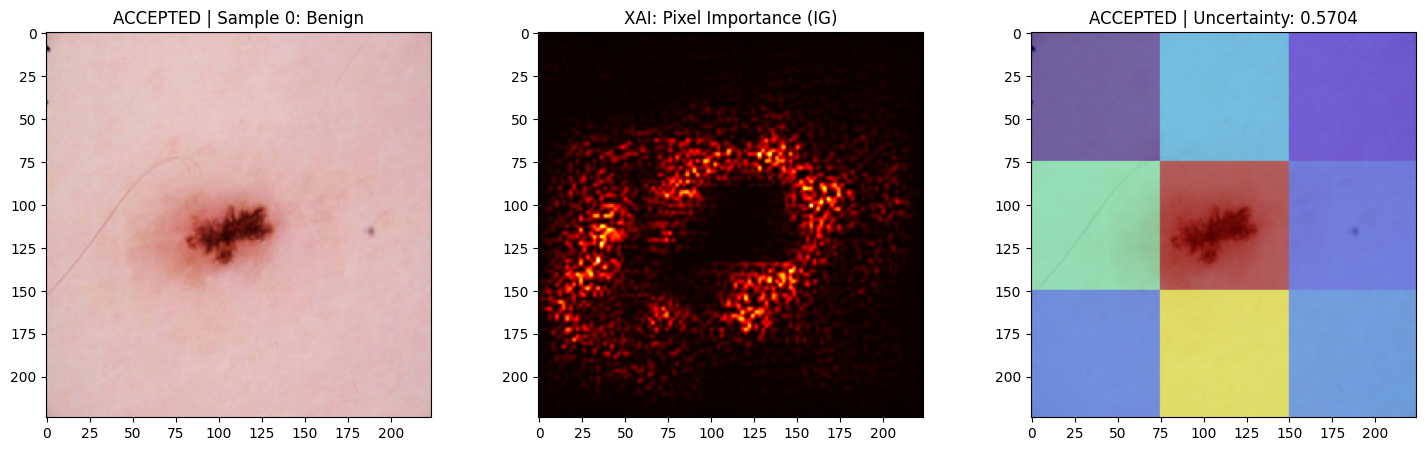

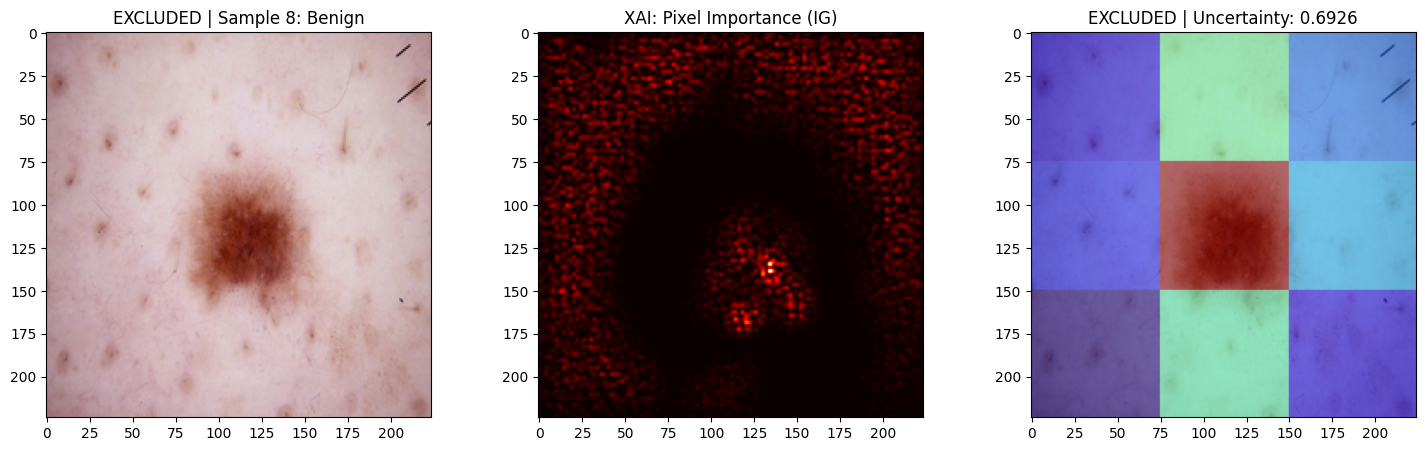

In [35]:
import pandas as pd

inc_mask = uncs < best_lam     # accepted
exc_mask = uncs >= best_lam    # excluded

def fixed_integrated_gradients(inputs, model, target_label_idx, steps=50):
    """Refined IG to focus strictly on the target class logit."""
    model.eval()
    baseline = torch.zeros_like(inputs).to(DEVICE)
    scaled_inputs = [baseline + (float(i) / steps) * (inputs - baseline) for i in range(0, steps + 1)]
    scaled_inputs = torch.cat(scaled_inputs).requires_grad_(True)
    outputs = model(scaled_inputs)
    class_outputs = outputs[:, target_label_idx]
    loss = class_outputs.sum()
    model.zero_grad()
    loss.backward()
    avg_grads = torch.mean(scaled_inputs.grad, dim=0)
    integrated_grad = (inputs.squeeze(0) - baseline.squeeze(0)) * avg_grads
    attribution = integrated_grad.sum(dim=0).detach().cpu().numpy()
    return np.maximum(attribution, 0) / (np.max(attribution) + 1e-8)
def plot_submission_gallery(test_ds, patch_model, num_samples=2):
    """Generates a gallery of results for both Benign and Malignant cases."""
    for target_class in [0]:
        accepted_indices = [i for i in range(len(labels)) 
                    if labels[i] == target_class and inc_mask[i]]
        
        excluded_indices = [i for i in range(len(labels)) 
                            if labels[i] == target_class and exc_mask[i]]
        
        # pick 1 from each
        selected = []
        
        if len(accepted_indices) > 0:
            selected.append(("ACCEPTED", accepted_indices[0]))
        
        if len(excluded_indices) > 0:
            selected.append(("EXCLUDED", excluded_indices[0]))

        
        for status, idx in selected:
            patches, label = test_ds[idx]
            label_name = "Benign" if label == 0 else "Malignant"
            center_patch = patches[4].unsqueeze(0).to(DEVICE)
            ig_map = fixed_integrated_gradients(center_patch, patch_model, target_label_idx=label)
            spatial_map = generate_spatial_uncertainty(patches, patch_model)
            img_path, _ = test_ds.data.samples[idx]
            img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (224, 224))
            fig, axes = plt.subplots(1, 3, figsize=(18, 5))
            axes[0].imshow(img)
            axes[0].set_title(f"{status} | Sample {idx}: {label_name}")
            axes[1].imshow(cv2.resize(ig_map, (224, 224)), cmap='hot')
            axes[1].set_title("XAI: Pixel Importance (IG)")
            spatial_res = cv2.resize(spatial_map, (224, 224), interpolation=cv2.INTER_NEAREST)
            axes[2].imshow(img)
            axes[2].imshow(spatial_res, cmap='jet', alpha=0.5)
            axes[2].set_title(f"{status} | Uncertainty: {uncs[idx]:.4f}")
            plt.show()
plot_submission_gallery(test_ds, patch_model)

In [30]:
import pandas as pd
results_data = {
    "Metric": [
        "Baseline Accuracy (Full Test Set)",
        "AUQantO Accuracy (Accepted Samples)",
        "Optimization Threshold (λ)",
        "Coverage (Accepted %)",
        "Rejection Rate (Excluded %)",
        "Accuracy Difference (AD)",
        "Abstain Percentage (AP)"
    ],
    "Value": [
        f"{baseline_acc*100:.2f}%",
        f"{acc_inc*100:.2f}%",
        f"{best_lam:.6f}",
        f"{coverage*100:.2f}%",
        f"{reject_rate*100:.2f}%",
        f"{AD:.4f}",
        f"{AP:.2f}%"
    ]
}
df_results = pd.DataFrame(results_data)
print("\nPROJECT SUMMARY REPORT\n")
display(df_results)
if acc_inc > baseline_acc:
    print(f"SUCCESS: AUQantO improved reliability by {(acc_inc - baseline_acc)*100:.2f} percentage points.")
else:
    print("NOTE: Accuracy is stable; look at AD to verify gain over rejected samples.")


PROJECT SUMMARY REPORT



,Metric,Value
0,Baseline Accuracy (Full Test Set),80.30%
1,AUQantO Accuracy (Accepted Samples),82.45%
2,Optimization Threshold (λ),0.685032
3,Coverage (Accepted %),91.52%
4,Rejection Rate (Excluded %),8.48%
5,Accuracy Difference (AD),0.3066
6,Abstain Percentage (AP),8.48%


SUCCESS: AUQantO improved reliability by 2.15 percentage points.
